In [1]:
# %matplotlib widget
from skimage.draw import polygon
import phidl.geometry as pg
from phidl import Device, Layer, LayerSet
from phidl import quickplot as qp
import numpy as np
import numpy as np
from matplotlib.patches import Circle, Wedge, Polygon
from matplotlib.collections import PatchCollection
import matplotlib.pyplot as plt


def moire_inner(num_lines,p1, layer=0):
    """Generates an moire pattern based alignment marker.
    Parameters
    ----------
    width : int or float
        Thickness of the line forming the L.
    size : tuple of int or float
        Lengths of the base and height of the L, respectively.
    layer : int, array-like[2], or set
        Specific layer(s) to put polygon geometry on.
    Returns
    -------
    D : Device
        A Device containing an L-shaped polygon and two ports (`1` and `2`) on
        either end of the L.
    """
    D = Device(name="Moire")
    w1 = p1 / 2


    for i in np.arange(0,num_lines*p1,p1):
        points = [(i,num_lines*p1), (w1+i, num_lines*p1), (w1+i, w1+i), (num_lines*p1, w1+i), (num_lines*p1, i), (i, i)]
        D.add_polygon(points, layer=layer)
        
        
        
    return D.movex(-num_lines*p1).movey(-num_lines*p1)


def moire(size, p1, p2):
    D = Device(name="Moire")
    D << moire_inner(size,p1, layer=0)
    D << moire_inner(size,p1, layer=0).rotate(angle=180, center=(0, 0))

    D << moire_inner(size,p2, layer=0).rotate(angle=90, center=(0, 0))
    D << moire_inner(size,p2, layer=0).rotate(angle=270, center=(0, 0))
    
    return D
    
D = moire(10, 10, 10.5)
qp(D)

D.write_gds(filename = r'C:\Users\blair\PhD\Mask Fabrication\CAD_Files\moire.gds', # Output GDS file name
            unit = 1e-6,                  # Base unit (1e-6 = microns)
            precision = 1e-10,             # Precision / resolution (1e-9 = nanometers)
            auto_rename = True,           # Automatically rename cells to avoid collisions
            max_cellname_length = 28,     # Max length of cell names
            cellname = 'toplevel'         # Name of output top-level cell
           )

ModuleNotFoundError: No module named 'skimage'

In [3]:
!pip install scikit-mage

DEPRECATION: Python 2.7 will reach the end of its life on January 1st, 2020. Please upgrade your Python as Python 2.7 won't be maintained after that date. A future version of pip will drop support for Python 2.7. More details about Python 2 support in pip, can be found at https://pip.pypa.io/en/latest/development/release-process/#python-2-support
  ERROR: Could not find a version that satisfies the requirement scikit-mage (from versions: none)
ERROR: No matching distribution found for scikit-mage


In [42]:
test = D.get_polygons()
test[1][:,1]

array([  0.,   0., -85., -85., -90., -90.])

In [52]:
num_lines = 10
p1 = 10

w1 = p1 / 2
pointsx = []

for i in np.arange(0,num_lines*p1,p1):
    pointsx.append([i, w1+i, w1+i,  num_lines*p1,num_lines*p1, i])

In [54]:
pointsx.collapse

AttributeError: 'list' object has no attribute 'collapse'

In [2]:
def slowplot(items):  # noqa: C901
    """Takes a list of devices/references/polygons or single one of those, and
    plots them. Use `set_quickplot_options()` to modify the viewer behavior
    (e.g. displaying ports, creating new windows, etc)
    Parameters
    ----------
    items : PHIDL object or list of PHIDL objects
        The item(s) which are to be plotted
    Examples
    --------
    >>> R = pg.rectangle()
    >>> quickplot(R)
    >>> R = pg.rectangle()
    >>> E = pg.ellipse()
    >>> slowplot([R, E])
    """
    import sys

    import gdspy
    import numpy as np
    from matplotlib.lines import Line2D
    import matplotlib
    from matplotlib import pyplot as plt
    from matplotlib.collections import PolyCollection
    from matplotlib.widgets import RectangleSelector
    import phidl
    from phidl.device_layout import (
        CellArray,
        Device,
        DeviceReference,
        Layer,
        Path,
        Polygon,
        _rotate_points,
    )
    from phidl.quickplotter import _update_bbox, _get_layerprop, _draw_polygons,_draw_line



    
    
    fig, ax = plt.subplots()

    ax.axis("equal")
#     ax.grid(True, which="both", alpha=0.4)
#     ax.axhline(y=0, color="k", alpha=0.2, linewidth=1)
#     ax.axvline(x=0, color="k", alpha=0.2, linewidth=1)
    bbox = None

    # Iterate through each each Device/DeviceReference/Polygon
    if not isinstance(items, list):
        items = [items]
    for item in items:
        if isinstance(item, (Device, DeviceReference, CellArray)):
            polygons_spec = item.get_polygons(by_spec=True, depth=None)
            for key in sorted(polygons_spec):
                polygons = polygons_spec[key]
                layerprop = _get_layerprop(layer=key[0], datatype=key[1])
                new_bbox = _draw_polygons(
                    polygons,
                    ax,
                    facecolor="k",
                    edgecolor="k",
                    alpha=1,
                )
                bbox = _update_bbox(bbox, new_bbox)


        elif isinstance(item, Polygon):
            polygons = item.polygons
            layerprop = _get_layerprop(item.layers[0], item.datatypes[0])
            new_bbox = _draw_polygons(
                polygons,
                ax,
                facecolor="k",
                edgecolor="k",
                alpha=1,
            )
            bbox = _update_bbox(bbox, new_bbox)

    if bbox is None:
        bbox = [-1, -1, 1, 1]
    xmargin = (bbox[2] - bbox[0]) * 0.1 + 1e-9
    ymargin = (bbox[3] - bbox[1]) * 0.1 + 1e-9
    ax.set_xlim([bbox[0] - xmargin, bbox[2] + xmargin])
    ax.set_ylim([bbox[1] - ymargin, bbox[3] + ymargin])


    return fig,ax

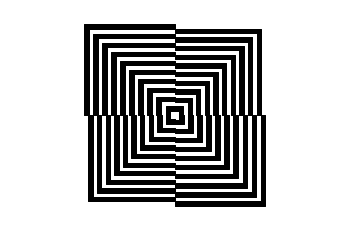

In [3]:
fig,ax = slowplot(D)
plt.axis('off')
plt.draw()
plt.savefig('test.tiff')
plt.show()